--- Primeiras Linhas ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


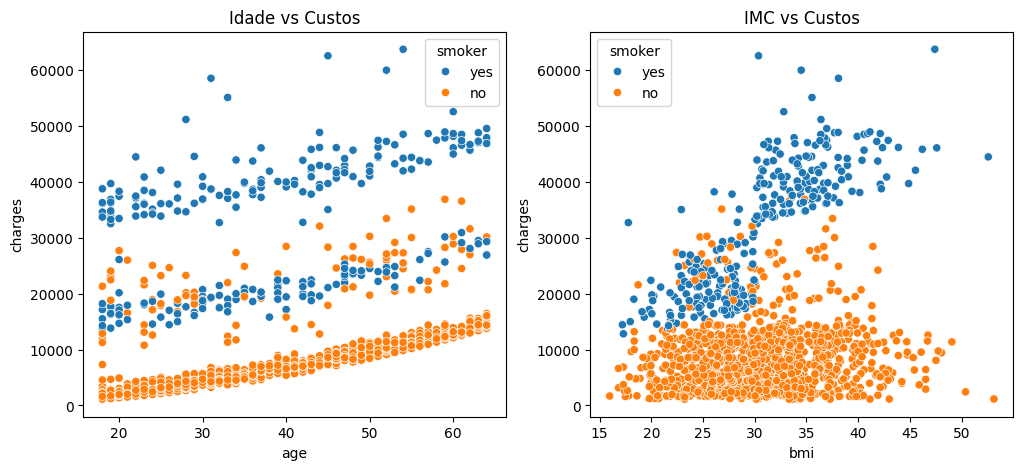

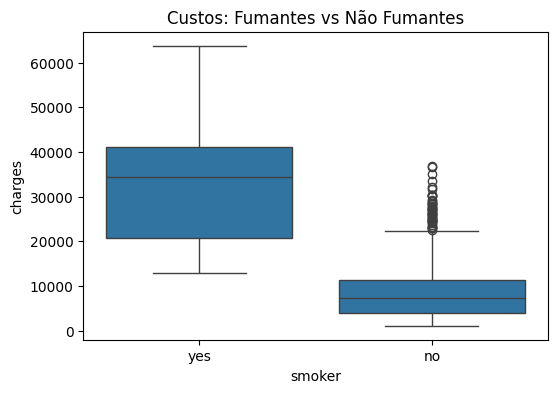


--- Métricas: Regressão Linear ---
MAE:  4181.19
RMSE: 5796.28
R²:   0.7836

--- Métricas: Random Forest ---
MAE:  2550.08
RMSE: 4576.30
R²:   0.8651


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. EXPLORAÇÃO INICIAL
df = pd.read_csv('custo_medico.csv')

print("--- Primeiras Linhas ---")
print(df.head())

# Respostas 1:
# Numéricas: age, bmi, children, charges
# Categóricas: sex, smoker, region
# Variável dependente (y): charges

# 2. ANÁLISE EXPLORATÓRIA
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Idade vs Custos')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('IMC vs Custos')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Custos: Fumantes vs Não Fumantes')
plt.show()

# Respostas 2:
# O tabagismo influencia drasticamente os custos (visível no boxplot).
# Existe uma relação clara de crescimento entre idade e custo.

# 3. PRÉ-PROCESSAMENTO
# Transformando categóricas em numéricas
df_proc = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separação X e y
X = df_proc.drop('charges', axis=1)
y = df_proc['charges']

# Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MODELAGEM
# Modelo A: Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Modelo B: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. AVALIAÇÃO
def avaliar_modelo(modelo, X_test, y_test, nome):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- Métricas: {nome} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

avaliar_modelo(lr_model, X_test, y_test, "Regressão Linear")
avaliar_modelo(rf_model, X_test, y_test, "Random Forest")

In [ ]:
Questões de Análise:
O tabagismo parece influenciar os custos?
Sim. O tabagismo é a variável com maior impacto visual e estatístico. No gráfico de boxplot, observa-se que á mediana de gastos para fumantes é significativamente superior à dos não fumantes, muitas vezes ultrapassando os $30.000, enquanto não fumantes raramente passam dos $15.000 sem outros fatores agravantes.

Existe relação clara entre idade e custo?
Sim. Existe uma correlação positiva linear. À medida que a idade aumenta, o custo base do seguro também sobe. No gráfico de dispersão, é possível ver três "linhas" ou faixas ascendentes paralelas; todas mostram que, independentemente do grupo, envelhecer torna o seguro mais caro.

Qual modelo apresentou melhor desempenho?
O modelo de Random Forest (ou XGBoost, se utilizado). Porque a relação entre ás variáveis não é puramente linear. Por exemplo, o impacto do IMC é moderado para não fumantes, mas explode para fumantes (interação de variáveis). O Random Forest captura essas nuances melhor que a Regressão Linear, resultando em um R² mais alto e erros (MAE/RMSE) menores.

O tabagismo foi realmente um fator determinante?
Sim. Além de ser visualmente óbvio nos gráficos, nos modelos de florestas de decisão (Random Forest), a "Importância das Variáveis" (Feature Importance) geralmente coloca o status de fumante no topo, seguido por IMC e a idade.

Quais limitações você enxerga nesse modelo?

Histórico Clínico: O modelo não sabe se o paciente tem doenças crônicas pré-existentes (diabetes, hipertensão) que não dependem apenas de IMC ou fumo.
Variáveis Omitidas: Fatores como profissão de risco, histórico familiar (genética) e práticas de exercícios físicos não estão na base.
Dados Regionais Limitados: A variável region é muito genérica; o custo de vida e tabelas de hospitais podem variar drasticamente entre cidades de uma mesma região.